In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [71]:
sns.set_theme(style='darkgrid')
custom_palette = ['#007B92', '#62CFC9', '#DC1F33', '#EFAC1E']
sns.set_palette(custom_palette)

In [11]:
df_complete = pd.read_csv('data/dispatch_data.csv')

In [33]:
df_representative = df_complete.groupby('case_id').first()

In [42]:
# Each case_id (each case) has exactly 9 activities
assert (df_complete.groupby('case_id')['activity'].count() - 9).sum() == 0

In [34]:
print('{} -- {}'.format(df_representative['timestamp'].min(), df_representative['timestamp'].max()))

2024-02-25 11:07:29.200 -- 2024-03-26 08:16:45.200


In [54]:
df_to_chancado = df_complete[df_complete['dumplocationunit'] == 'Chancado']
df_to_chancado_unique = df_to_chancado.groupby(by='case_id').first()

In [55]:
print(f'Chancado has {df_to_chancado_unique.shape[0] / df_complete['case_id'].nunique():.2%} of total dumping')

Chancado has 40.32% of total dumping


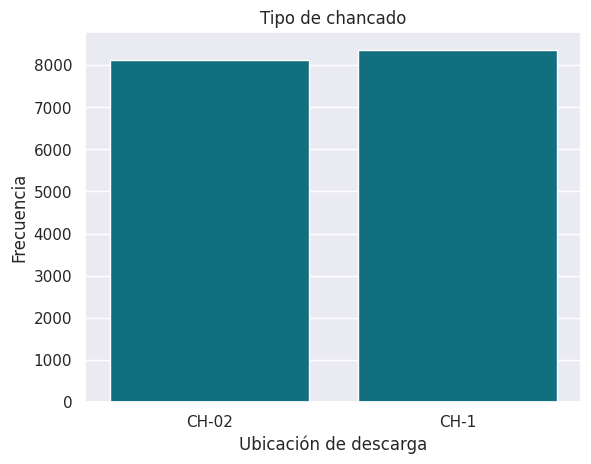

In [57]:
# Consider that this is only the 40.32% of all cases
sns.countplot(df_to_chancado_unique, x='dumplocation').\
    set(title='Tipo de chancado', ylabel='Frecuencia', xlabel='Ubicación de descarga');

In [58]:
df_to_chancado_unique.head()

,activity,timestamp,resource,crew,shiftname,loadlocationunit,excav,loadlocation,truck,shiftname.1,dumplocation,dumplocationunit
case_id,,,,,,,,,,,,
7760,Assign Carga,2024-03-20 02:52:32.200,Loreto Jopia Cepeda,G4,240320a,Disparo,PA,F9,CA90,240320a,CH-02,Chancado
7762,Assign Carga,2024-03-20 02:45:01.200,Abisag Aguilera Arredondo,G4,240320a,Disparo,PA,F9,CA96,240320a,CH-02,Chancado
7766,Assign Carga,2024-03-20 02:19:54.200,Angela Moreno Brito,G4,240320a,Disparo,PA,F10,CA99,240320a,CH-02,Chancado
7767,Assign Carga,2024-03-20 02:17:39.200,Daniel Barrios Moroso,G4,240320a,Disparo,PA,F10,CA58,240320a,CH-02,Chancado
7769,Assign Carga,2024-03-20 02:49:10.200,Sebastian Oliva Brito,G4,240320a,Disparo,PA,F9,CA108,240320a,CH-02,Chancado


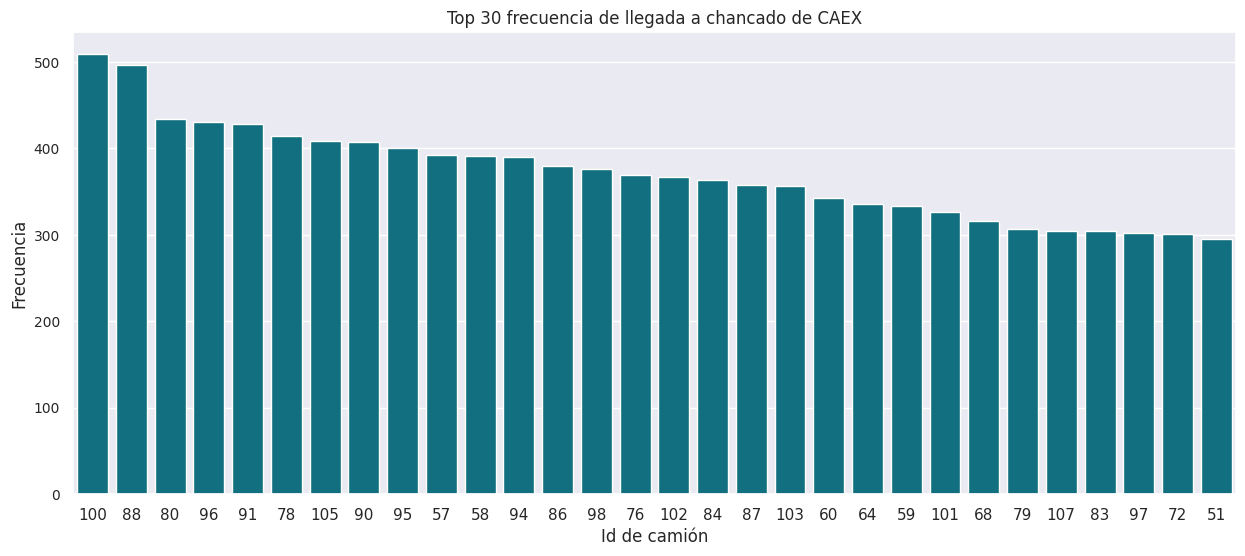

In [123]:
# Frecuencia por camión durante este mes
df_by_truck_sorted = df_to_chancado_unique.reset_index().\
                                           groupby(by='truck')[['case_id']].\
                                           count().\
                                           rename(columns={'case_id': 'count'}).\
                                           reset_index().\
                                           sort_values(by='count', ascending=False)

TOP_N = 30
df_subset_trucks = df_by_truck_sorted.head(TOP_N)
df_subset_trucks.loc[:,'truck'] = df_subset_trucks['truck'].str[2:]
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(15, 6))
sns.barplot(df_subset_trucks, x='truck', y='count', ax=ax)
ax.set(title=f'Top {TOP_N} frecuencia de llegada a chancado de CAEX', xlabel='Id de camión', ylabel='Frecuencia')
plt.yticks(fontsize=10);

In [133]:
# Check the turn information
df_log = pd.read_csv('data/full_event_log_v3.csv')

In [104]:
df_log.head()

,case_id,activity,timestamp,timestamp_end,shiftid
0,CA100,Fin traslado a carga,2024-02-27 14:01:01.900,2024-02-27 14:01:01.900,240227002
1,CA100,Carga,2024-02-27 14:05:56.100,2024-02-27 14:07:50.900,240227002
2,CA100,Inicio traslado a descarga,2024-02-27 14:07:51.100,2024-02-27 14:07:51.100,240227002
3,CA100,Fin traslado a descarga,2024-02-27 14:27:52.900,2024-02-27 14:27:52.900,240227002
4,CA100,Descarga,2024-02-27 14:29:21.100,2024-02-27 14:30:13.900,240227002


In [124]:
print(df_log[df_log['shiftid'] == 240312001]['timestamp'].max())
print(df_log[df_log['shiftid'] == 240312001]['timestamp'].min())

2024-03-12 11:57:00.000
2024-03-11 20:59:59.900


In [128]:
df_log[df_log['shiftid'] == 240312001].sort_values('timestamp').head(20)

,case_id,activity,timestamp,timestamp_end,shiftid
188242,CA86,Fin traslado a descarga,2024-03-11 20:59:59.900,2024-03-11 20:59:59.900,240312001
143720,CA77,Fin traslado a descarga,2024-03-11 20:59:59.900,2024-03-11 20:59:59.900,240312001
64185,CA57,Fin traslado a descarga,2024-03-11 20:59:59.900,2024-03-11 20:59:59.900,240312001
188243,CA86,Descarga,2024-03-11 21:00:00.100,2024-03-11 20:59:59.900,240312001
64186,CA57,Descarga,2024-03-11 21:00:00.100,2024-03-11 20:59:59.900,240312001
143721,CA77,Descarga,2024-03-11 21:00:00.100,2024-03-11 20:59:59.900,240312001
124319,CA72,Inicio traslado a carga,2024-03-11 22:05:44.100,2024-03-11 22:05:44.100,240312001
46899,CA50,Inicio traslado a carga,2024-03-11 22:09:11.100,2024-03-11 22:09:11.100,240312001
148434,CA78,Inicio traslado a carga,2024-03-11 22:10:05.100,2024-03-11 22:10:05.100,240312001
124320,CA72,Fin traslado a carga,2024-03-11 22:10:13.900,2024-03-11 22:10:13.900,240312001
